In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

events_mapping = {
    "session_start": 0,
    "main": 1,
    "sign_in": 2,
    "registration_page": 3,
    "registration": 4,
    "forgot_password_page": 5,
    "reset_password_page": 6,
    "account_page": 7,
    "product_list_view": 8,
    "search": 9,
    "view_search_results": 10,
    "store_page": 11,
    "store_item_page": 12,
    "view_item_list": 13,
    "product_view": 14,
    "wishlist_page": 15,
    "add_to_cart": 16,
    "basket": 17,
    "shipping_details": 18,
    "payment_details": 19,
    "review_order": 20,
    "purchase": 21,
}

In [4]:
%%time
ecom_df = pd.read_csv("data/ecom_shop.csv.gz")

sessions_df = (
    ecom_df
        .sort_values(
            [
                "session_id",
                "event_order", 
                "timestamp"
            ]
        )
        .assign(
            event_idx=lambda d: d.groupby("session_id").cumcount()
        )
        .drop_duplicates(subset=["timestamp"])
        .pipe(
                lambda d: d.pivot(index="session_id", columns="event_idx", values="event")
                        .add_prefix("event_")
                        .join(d.groupby("session_id")["is_old_user"].first())
                        .reset_index()
                        .rename_axis(None, axis=1)
        )
)

event_cols = (
    sessions_df
        .columns
        .copy()
        .delete([0, -1]) # drop session_id, is_old_user
)

CPU times: user 1.76 s, sys: 289 ms, total: 2.05 s
Wall time: 2.12 s


In [5]:
%%time
# markov embedding model
session_sequences = sessions_df[event_cols].apply(lambda row: row.dropna().tolist(), axis=1)

n_events = len(events_mapping)

def session_transition_prob(seq, mapping):
    mat = np.zeros((n_events, n_events), dtype=np.float32)
    ids = [mapping[e] for e in seq if e in mapping]
    for a, b in zip(ids[:-1], ids[1:]):
        mat[a, b] += 1
    row_sums = mat.sum(axis=1, keepdims=True)
    mat = np.divide(mat, row_sums, out=np.zeros_like(mat), where=row_sums != 0)
    return mat.flatten()

X_markov = np.vstack([
    session_transition_prob(seq, events_mapping)
    for seq in session_sequences
])

X_markov.shape

CPU times: user 43 s, sys: 830 ms, total: 43.8 s
Wall time: 43.9 s


(116092, 484)

In [7]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_markov)

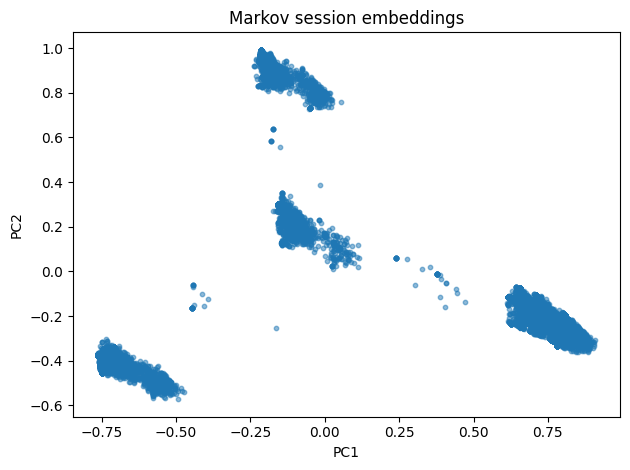

In [9]:
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=10, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Markov session embeddings")
plt.tight_layout()
plt.show()